<a href="https://colab.research.google.com/github/ExcWasHere/PCVK_2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


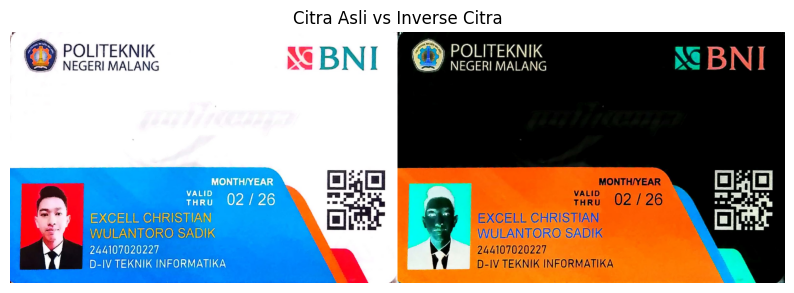

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')

inverse_image = 255 - original

final = cv.hconcat((original, inverse_image))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
plt.title('Citra Asli vs Inverse Citra')
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah kontras dan tingkat kecerahan citra')
print('--------------------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan : '))
    contrast = float(input('Masukkan kontras : '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg').astype(np.float32)

factor = (259 * (contrast + 255)) / (255 * (259 - contrast))
contrast_image = factor * (original - 128) + 128 + brightness
contrast_image = np.clip(contrast_image, 0, 255).astype(np.uint8)

final = cv.hconcat((original.astype(np.uint8), contrast_image))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
plt.title(f'Kontras={contrast}, Brightness={brightness}')
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('---------------------------------------------------------')
try:
    k = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg').astype(np.float32)

r = original * (1 + k/100)
c = 255 / np.log(1 + 255*(1 + k/100))
log_image = c * np.log(1 + r)
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final = cv.hconcat((original.astype(np.uint8), log_image))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
plt.title(f'Transformasi Log, kecerahan={k}')
plt.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)
R, G, B = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]

gray_avg = ((R + G + B) / 3).astype(np.uint8)
gray_light = ((np.maximum(np.maximum(R,G),B) + np.minimum(np.minimum(R,G),B)) / 2).astype(np.uint8)
gray_lum = (0.21*R + 0.72*G + 0.07*B).astype(np.uint8)

fig, ax = plt.subplots(2, 3, figsize=(12,8))
ax[0,0].imshow(img_rgb.astype(np.uint8)); ax[0,0].set_title('Asli (Averaging pair)')
ax[0,1].imshow(img_rgb.astype(np.uint8)); ax[0,1].set_title('Asli (Lightness pair)')
ax[0,2].imshow(img_rgb.astype(np.uint8)); ax[0,2].set_title('Asli (Luminance pair)')
ax[1,0].imshow(gray_avg, cmap='gray'); ax[1,0].set_title('Averaging')
ax[1,1].imshow(gray_light, cmap='gray'); ax[1,1].set_title('Lightness')
ax[1,2].imshow(gray_lum, cmap='gray'); ax[1,2].set_title('Luminance')
for a in ax.ravel(): a.axis('off')
plt.tight_layout()
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


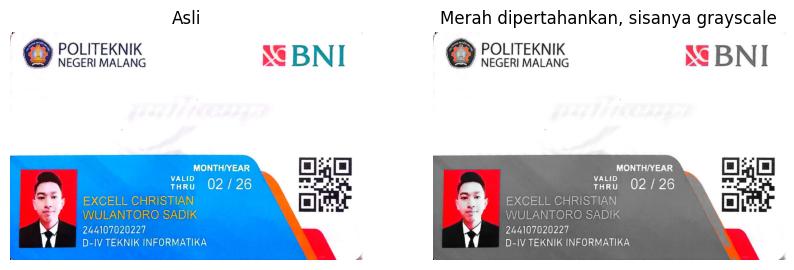

In [8]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

lower1, upper1 = np.array([0,70,50]), np.array([10,255,255])
lower2, upper2 = np.array([170,70,50]), np.array([180,255,255])
mask = cv.bitwise_or(cv.inRange(hsv, lower1, upper1), cv.inRange(hsv, lower2, upper2))

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

result = np.where(mask[:,:,None] == 255, img_rgb, gray_3ch)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(img_rgb); ax[0].set_title('Asli'); ax[0].axis('off')
ax[1].imshow(result); ax[1].set_title('Merah dipertahankan, sisanya grayscale'); ax[1].axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)

gamma_image = 255 * np.power(img_rgb/255, 1/gamma)
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Citra Asli'); ax[0].axis('off')
ax[1].imshow(gamma_image); ax[1].set_title(f'Gamma Correction (γ = {gamma})'); ax[1].axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg', cv.IMREAD_GRAYSCALE)
depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

print(f'Bit depth awal  : 8 bit')
print(f'Bit depth tujuan: {bit_depth} bit')
print(f'Jumlah level    : {pow(2, bit_depth)}')

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(original, cmap='gray'); ax[0].set_title('Grayscale 8-bit'); ax[0].axis('off')
ax[1].imshow(depth_image, cmap='gray'); ax[1].set_title(f'Grayscale {bit_depth}-bit'); ax[1].axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from math import sqrt, log10

def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    return 20 * log10(max_pixel / sqrt(mse))

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')

cv_img = []
for f in glob.glob('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg'):
    cv_img.append(cv.imread(f))

jumlah_list = [10, 20, 40, 80, 100]
hasil_psnr = []

fig, axes = plt.subplots(1, len(jumlah_list), figsize=(18,4))
for ax, n in zip(axes, jumlah_list):
    avg = np.mean(cv_img[:n], axis=0).astype(np.uint8)
    psnr = PSNR(original, avg)
    hasil_psnr.append(psnr)
    ax.imshow(cv.cvtColor(avg, cv.COLOR_BGR2RGB))
    ax.set_title(f'N={n}\nPSNR={psnr:.2f}dB')
    ax.axis('off')
plt.show()

for n, p in zip(jumlah_list, hasil_psnr):
    print(f'Jumlah citra: {n:3d} -> PSNR: {p:.2f} dB')

In [ ]:
#image masking
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
h, w = original.shape[:2]

maskA = np.zeros((h,w), np.uint8)
maskB = np.zeros((h,w), np.uint8)
cv.circle(maskA, (w//4, h//2), min(h,w)//5, 255, -1)
cv.circle(maskB, (3*w//4, h//2), min(h,w)//5, 255, -1)

operators = {
    'NOT (komplemen)': cv.bitwise_not(maskA),
    'OR (Atau)': cv.bitwise_or(maskA, maskB),
    'AND (Dan)': cv.bitwise_and(maskA, maskB),
    'NAND (Not And)': cv.bitwise_not(cv.bitwise_and(maskA, maskB)),
    'XOR (Exclusive Or)': cv.bitwise_xor(maskA, maskB),
}

fig, axes = plt.subplots(1, len(operators), figsize=(20,4))
for ax, (name, mask) in zip(axes, operators.items()):
    output = cv.bitwise_and(original, original, mask=mask)
    ax.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg')
img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)

gamma = 0.5
gamma_image = 255 * np.power(img_rgb/255, 1/gamma)
gamma_image = np.clip(gamma_image, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(img_rgb.astype(np.uint8)); ax[0].set_title('Foto Asli'); ax[0].axis('off')
ax[1].imshow(gamma_image); ax[1].set_title(f'Gamma Correction γ={gamma}'); ax[1].axis('off')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

original = cv.imread('/content/drive/MyDrive/Pindahan Dokumen/ktm_exc_scan.jpeg').astype(np.float32)

contrast = 1.4
factor = (259 * (contrast + 255)) / (255 * (259 - contrast))
step1 = factor * (original - 128) + 128
step1 = np.clip(step1, 0, 255)
gamma = 0.85
step2 = 255 * np.power(step1/255, 1/gamma)
final = np.clip(step2, 0, 255).astype(np.uint8)

result = cv.hconcat((original.astype(np.uint8), final))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('Before (kiri) - After (kanan)')
plt.axis('off')
plt.show()